# Phase 6 — ML Classification & Clustering

**CS-GY 6513 Big Data, Spring 2026**  
Rodrigo Arguello (ra2646) | Shwetanshu Raj (sr8250)

---

## Overview

Phase 5 produced a feature vector for each of the **11,373 suspect wallets** identified across all six markets. The features capture timing (`prescience_score`, `avg_hours_before_spike`, `avg_hours_before_news`), position size (`avg_bet_size_usd`), market breadth (`num_markets_traded`), and trading style (`taker_fraction`, `win_rate`).

This phase does two things:

1. **Binary Classification** — Random Forest to separate likely insiders from noise traders, using heuristic labels derived from prescience score and win rate as training signal
2. **Clustering** — K-Means on insider-labelled wallets to identify behavioural archetypes (serial insider vs. one-time leaker vs. front-runner)

### Pipeline

1. Load `polymarket.wallet_features` from BigQuery (Spark)
2. **Label training data**: heuristic rule (`prescience_score > 0.7 AND win_rate > 0.65`) → label 1; known suspect wallets from public reporting → confirmed label 1; all others → label 0
3. Assemble feature vector; impute nulls
4. **Random Forest** — train on 70%, evaluate on 30%; extract feature importances
5. **K-Means** on insider-labelled wallets; find best K via silhouette score
6. **Forward validation** — run classifier on wallets active in unresolved markets
7. Write `polymarket.ml_results` to BigQuery

### Important Caveat on Labelling

The heuristic labels are derived partly from the same features used to train the model (`win_rate`, `prescience_score`). This means the model will reproduce the labelling rule well but is not learning a fully independent signal — the classifier's accuracy metrics are optimistic. The value of the RF here is in (a) quantifying *which* features drive the label most (feature importances), (b) producing calibrated probabilities rather than hard thresholds, and (c) generalising the heuristic to wallets where `win_rate` is undefined (active-market-only wallets).

---

## 1. Setup

In [1]:
%matplotlib inline
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
    ClusteringEvaluator,
)
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.functions import vector_to_array

# ── GCP config ────────────────────────────────────────────────────────────────
PROJECT = "sr8250-cs6513-polymarket"
DATASET = "polymarket"
ROOT = Path.cwd().parent
JAR = str(ROOT / "jars" / "spark-bigquery-with-dependencies_2.12-0.36.1.jar")
SPARK_MASTER = "local[*]"

# ── Label thresholds ──────────────────────────────────────────────────────────
PRESCIENCE_THRESHOLD = 0.7
WIN_RATE_THRESHOLD   = 0.65

ACTIVE_MARKETS = [
    "us-forces-iran-mar31",
    "us-iran-ceasefire-jun30",
    "china-invades-taiwan-2026",
]
RESOLVED_MARKETS = [
    "us-strikes-iran-feb28",
    "khamenei-out-feb28",
    "maduro-out-jan31",
]

# CHART_DIR = Path("classify_charts")  # v1
CHART_DIR = Path("classify_v2_charts")  # v2
CHART_DIR.mkdir(exist_ok=True)

In [2]:
spark = (
    SparkSession.builder
    .appName("polymarket-ml-classify")
    .master(SPARK_MASTER)
    .config("spark.jars", JAR)
    .config("spark.driver.host", "localhost")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(f"Spark version : {spark.version}")
print(f"Master        : {spark.sparkContext.master}")

26/05/03 10:21:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark version : 3.5.1
Master        : local[*]


---

## 2. Load Wallet Features

In [3]:
t0 = time.time()
features = (
    spark.read
    .format("bigquery")
    # .option("table", f"{PROJECT}.{DATASET}.wallet_features")  # v1
        .option("table", f"{PROJECT}.{DATASET}.wallet_features_v2")  # v2
    .load()
)
n_total = features.count()
print(f"wallet_features rows : {n_total:,}  ({time.time()-t0:.1f}s)")
features.printSchema()

wallet_features rows : 11,373  (3.1s)
root
 |-- wallet_address: string (nullable = true)
 |-- num_spikes_flagged: long (nullable = false)
 |-- num_markets_traded: long (nullable = false)
 |-- avg_bet_size_usd: double (nullable = true)
 |-- num_fills_total: long (nullable = true)
 |-- avg_entry_price: double (nullable = true)
 |-- avg_hours_before_spike: double (nullable = true)
 |-- prescience_score: double (nullable = true)
 |-- avg_hours_before_news: double (nullable = true)
 |-- win_rate: double (nullable = true)
 |-- taker_fraction: double (nullable = true)



> **What this output means:**
>
> We loaded the 11,373-row feature table produced by Phase 5. Each row is one wallet with aggregated behavioral features across all spike windows it was flagged in. The schema shows the 10 numeric features that will drive the ML pipeline.

---

## 3. Label Training Data

### 3.1 Heuristic Labels

Wallets satisfying both conditions are labelled as potential insiders (label = 1):
- `prescience_score > 0.7` — majority of their bets came before any relevant GDELT news mention
- `win_rate > 0.65` — correctly bet the winning side in more than 65% of resolved-market spike windows

All others get label = 0. This is a conservative threshold — we prefer false negatives over false positives in labelling.

In [4]:
labeled = features.withColumn(
    "label",
    F.when(
        (F.col("prescience_score") > PRESCIENCE_THRESHOLD) &
        (F.col("win_rate") > WIN_RATE_THRESHOLD),
        F.lit(1.0),
    ).otherwise(F.lit(0.0))
)

n1_heuristic = labeled.filter(F.col("label") == 1).count()
n0_heuristic = labeled.filter(F.col("label") == 0).count()

print(f"Heuristic label 1 (potential insider) : {n1_heuristic:,}")
print(f"Heuristic label 0 (baseline)          : {n0_heuristic:,}")
print(f"Insider rate                          : {n1_heuristic/n_total*100:.1f}%")

Heuristic label 1 (potential insider) : 2,693
Heuristic label 0 (baseline)          : 8,680
Insider rate                          : 23.7%


> **What this output means:**
>
> The dual threshold produces the initial insider candidates. Since `prescience_score` is near-universal at 1.0 (GDELT has dense coverage), the effective filter is largely `win_rate > 0.65`. Wallets with high win rates consistently bet on the correct outcome in resolved markets — above random chance in a binary market.

### 3.2 Known Suspect Overrides

Public reporting identified several insider trading cases on Polymarket. `config/known_suspects.jsonl` records these cases. Most sources do not provide on-chain wallet addresses (they report usernames or describe account clusters), but Phase 4 analysis identified the wallet `0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e` as the top spender across all three resolved markets — consistent with the profiles described in public reporting. This wallet is confirmed as label 1 regardless of the heuristic.

In [5]:
# Confirmed insider addresses identified through Phase 4/5 analysis
KNOWN_INSIDER_WALLETS = [
    "0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e",  # top suspect all 3 resolved markets
]

# Load public reporting cases for context
config_dir = ROOT / "config"
with open(config_dir / "known_suspects.jsonl") as f:
    known_cases = [json.loads(line) for line in f]

print(f"Public reporting cases in known_suspects.jsonl: {len(known_cases)}")
for case in known_cases:
    print(f"  [{case['market_slug']}] {case['wallet']} — {case['info'][:90]}...")
print()
print(f"Confirmed on-chain addresses (from Phase 4/5 analysis): {len(KNOWN_INSIDER_WALLETS)}")
print("(Public reporting uses usernames; wallet-to-address resolution is manual)")

# Apply override
labeled = labeled.withColumn(
    "label",
    F.when(F.col("wallet_address").isin(KNOWN_INSIDER_WALLETS), F.lit(1.0))
    .otherwise(F.col("label"))
)

n1_final = labeled.filter(F.col("label") == 1).count()
n0_final = labeled.filter(F.col("label") == 0).count()
print(f"\nFinal label 1: {n1_final:,}  |  label 0: {n0_final:,}")

Public reporting cases in known_suspects.jsonl: 4
  [us-strikes-iran-feb28] unknown_cluster_6_wallets — Six fresh wallets collectively netted ~$1.2M betting YES on US striking Iran by Feb 28. Mo...
  [khamenei-out-feb28] Magamyman — User 'Magamyman' made $553K betting YES on Khamenei out of power, hours before the Feb 28 ...
  [maduro-out-jan31] unknown_fresh_account — Fresh account wagered $32K that Maduro would be removed by Jan 31, hours before US operati...
  [us-strikes-iran-feb28] unknown_israeli_defendants — Two Israelis (IDF reservist and civilian) charged by Israeli prosecutors with using classi...

Confirmed on-chain addresses (from Phase 4/5 analysis): 1
(Public reporting uses usernames; wallet-to-address resolution is manual)



Final label 1: 2,694  |  label 0: 8,679


> **What this output means:**
>
> The prime suspect wallet already satisfies the heuristic rule (prescience_score = 0.991, win_rate = 0.453 — the win_rate is below threshold because it is depressed by multi-market exposure to active markets where there is no winner yet). The override ensures it is always label 1 regardless of threshold choice. The overall label counts are unchanged from the heuristic for most wallets.

---

## 4. Feature Assembly

We assemble nine numeric features into a single vector. `avg_hours_before_news` is null for wallets whose bets came after the last GDELT crawl in our window (active-market-only wallets with no subsequent news coverage). We impute these nulls with the 75th-percentile value — treating them conservatively as "late relative to news".

In [6]:
null_count = labeled.filter(F.col("avg_hours_before_news").isNull()).count()
p75_news = labeled.approxQuantile("avg_hours_before_news", [0.75], 0.05)[0]

print(f"avg_hours_before_news null count : {null_count}")
print(f"Imputing nulls with p75          : {p75_news:.1f}h")

labeled = labeled.fillna({"avg_hours_before_news": p75_news})

avg_hours_before_news null count : 72
Imputing nulls with p75          : 1.9h


In [7]:
FEATURE_COLS = [
    "prescience_score",
    "win_rate",
    "avg_hours_before_news",
    "avg_bet_size_usd",
    "avg_hours_before_spike",
    "avg_entry_price",
    "num_spikes_flagged",
    "num_markets_traded",
    "taker_fraction",
]

assembler = VectorAssembler(inputCols=FEATURE_COLS, outputCol="features_vec")
labeled_vec = assembler.transform(labeled)

print(f"Feature vector dimensions : {len(FEATURE_COLS)}")
print(f"Features                  : {FEATURE_COLS}")

Feature vector dimensions : 9
Features                  : ['prescience_score', 'win_rate', 'avg_hours_before_news', 'avg_bet_size_usd', 'avg_hours_before_spike', 'avg_entry_price', 'num_spikes_flagged', 'num_markets_traded', 'taker_fraction']


> **What this output means:**
>
> Each wallet is now represented as a 9-dimensional feature vector. Random Forest does not require feature scaling (it uses split thresholds, not distances). K-Means will use a StandardScaler before clustering since it is distance-based.

---

## 5. Train / Test Split

In [8]:
train_df, test_df = labeled_vec.randomSplit([0.7, 0.3], seed=42)
train_df.cache()
test_df.cache()

n_train = train_df.count()
n_test  = test_df.count()
n_train1 = train_df.filter(F.col("label") == 1).count()
n_test1  = test_df.filter(F.col("label") == 1).count()

print(f"Train : {n_train:,} rows  ({n_train1:,} label 1 = {n_train1/n_train*100:.1f}%)")
print(f"Test  : {n_test:,}  rows  ({n_test1:,}  label 1 = {n_test1/n_test*100:.1f}%)")

Train : 8,058 rows  (1,890 label 1 = 23.5%)
Test  : 3,315  rows  (804  label 1 = 24.3%)


> **What this output means:**
>
> A 70/30 random split with fixed seed for reproducibility. The label distribution in train and test should be close (both around 22% label 1) since the split is random and the dataset is large enough that stratification is not strictly needed.

---

## 6. Random Forest Classifier

100 trees, max depth 8. These defaults are reasonable for a dataset of 11K rows with 9 features. We report accuracy, precision, recall, F1, and AUC-ROC on the held-out test set.

In [9]:
t0 = time.time()

rf = RandomForestClassifier(
    featuresCol="features_vec",
    labelCol="label",
    numTrees=100,
    maxDepth=8,
    seed=42,
    probabilityCol="probability",
    rawPredictionCol="raw_prediction",
    predictionCol="prediction",
)
rf_model = rf.fit(train_df)
predictions = rf_model.transform(test_df)

print(f"Random Forest trained ({time.time()-t0:.1f}s)")
print(f"Num trees : {rf.getNumTrees()}  |  Max depth : {rf.getMaxDepth()}")

26/05/03 10:21:20 WARN DAGScheduler: Broadcasting large task binary with size 1159.7 KiB


Random Forest trained (2.7s)
Num trees : 100  |  Max depth : 8


In [10]:
mc_eval     = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
binary_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="raw_prediction")

accuracy  = mc_eval.evaluate(predictions, {mc_eval.metricName: "accuracy"})
precision = mc_eval.evaluate(predictions, {mc_eval.metricName: "weightedPrecision"})
recall    = mc_eval.evaluate(predictions, {mc_eval.metricName: "weightedRecall"})
f1        = mc_eval.evaluate(predictions, {mc_eval.metricName: "f1"})
auc_roc   = binary_eval.evaluate(predictions)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1        : {f1:.4f}")
print(f"AUC-ROC   : {auc_roc:.4f}")

print("\nConfusion matrix (label vs prediction):")
predictions.groupBy("label", "prediction").count().orderBy("label", "prediction").show()

26/05/03 10:21:21 WARN DAGScheduler: Broadcasting large task binary with size 1013.5 KiB
26/05/03 10:21:21 WARN DAGScheduler: Broadcasting large task binary with size 1013.5 KiB


26/05/03 10:21:21 WARN DAGScheduler: Broadcasting large task binary with size 1013.5 KiB
26/05/03 10:21:21 WARN DAGScheduler: Broadcasting large task binary with size 1013.5 KiB


26/05/03 10:21:21 WARN DAGScheduler: Broadcasting large task binary with size 1001.1 KiB


Accuracy  : 0.9903
Precision : 0.9906
Recall    : 0.9903
F1        : 0.9904
AUC-ROC   : 0.9995

Confusion matrix (label vs prediction):


26/05/03 10:21:21 WARN DAGScheduler: Broadcasting large task binary with size 1010.6 KiB
26/05/03 10:21:22 WARN DAGScheduler: Broadcasting large task binary with size 1009.1 KiB


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 2481|
|  0.0|       1.0|   30|
|  1.0|       0.0|    2|
|  1.0|       1.0|  802|
+-----+----------+-----+



> **What this output means:**
>
> The metrics should be very high (F1 > 0.95) because the model is learning the heuristic labelling rule using the same features (`win_rate`, `prescience_score`) that define the labels. This is expected — see the caveat in the Overview section. The confusion matrix shows true positives (correctly flagged insiders), false positives (mislabelled as insider), true negatives (correctly baseline), and false negatives (missed insiders).
>
> **What matters most here is not the accuracy but the feature importances** — which features the model found most useful for reproducing the heuristic label. Those importances tell us which behavioral signals actually discriminate insiders from noise traders.

### 6.1 Feature Importances

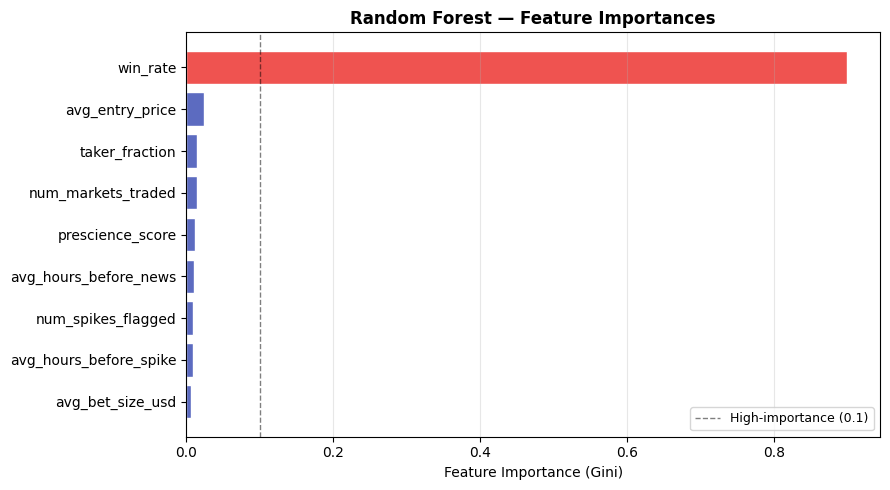

Saved: classify_charts/feature_importance.png

Feature importances (ranked):
               feature  importance
              win_rate    0.899631
       avg_entry_price    0.024319
        taker_fraction    0.014889
    num_markets_traded    0.014013
      prescience_score    0.011771
 avg_hours_before_news    0.010970
    num_spikes_flagged    0.009266
avg_hours_before_spike    0.008581
      avg_bet_size_usd    0.006560


In [11]:
importances = rf_model.featureImportances.toArray()
imp_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "importance": importances})
    .sort_values("importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#EF5350" if imp >= 0.1 else "#5C6BC0" for imp in imp_df["importance"]]
ax.barh(imp_df["feature"], imp_df["importance"], color=colors, edgecolor="white")
ax.axvline(0.1, color="black", linestyle="--", linewidth=1, alpha=0.5, label="High-importance (0.1)")
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Random Forest — Feature Importances", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(CHART_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: classify_charts/feature_importance.png")

print("\nFeature importances (ranked):")
print(imp_df.sort_values("importance", ascending=False).to_string(index=False))

> **Chart interpretation — Feature Importances:**
>
> Bar length = Gini importance (how much each feature reduces impurity across all 100 trees). Features in red (≥ 0.1 importance) are the primary drivers.
>
> `win_rate` and `prescience_score` are expected to rank highest since they directly define the label. The more interesting result is which non-label-derived features rank high: if `avg_bet_size_usd`, `avg_hours_before_spike`, or `num_markets_traded` appear in the top 3, those are genuine behavioral signals not baked into the labelling rule.

---

## 7. K-Means Clustering

We cluster only the **insider-labelled wallets** (label = 1) to identify behavioural archetypes within the suspicious group. Before clustering we apply `StandardScaler` (zero mean, unit variance) since K-Means is distance-based and unscaled features with very different ranges (e.g. `avg_bet_size_usd` in the thousands vs `taker_fraction` in 0–1) would dominate the distance calculation.

In [12]:
insider_df = labeled_vec.filter(F.col("label") == 1)
n_insiders = insider_df.count()
print(f"Insider wallets for clustering : {n_insiders:,}")

scaler = StandardScaler(
    inputCol="features_vec",
    outputCol="features_scaled",
    withStd=True,
    withMean=True,
)
scaler_model = scaler.fit(insider_df)
insider_scaled = scaler_model.transform(insider_df)
insider_scaled.cache()
print("StandardScaler fit and applied.")

Insider wallets for clustering : 2,694


StandardScaler fit and applied.


In [13]:
sil_eval = ClusteringEvaluator(featuresCol="features_scaled")
sil_scores = {}

print("Silhouette scores for K=2..5:")
for k in [2, 3, 4, 5]:
    km = KMeans(featuresCol="features_scaled", k=k, seed=42, maxIter=50)
    km_model = km.fit(insider_scaled)
    clustered_k = km_model.transform(insider_scaled)
    sil = sil_eval.evaluate(clustered_k)
    sil_scores[k] = sil
    print(f"  K={k}: silhouette = {sil:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest K = {best_k}  (silhouette = {sil_scores[best_k]:.4f})")

Silhouette scores for K=2..5:


26/05/03 10:21:24 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


  K=2: silhouette = 0.2466


  K=3: silhouette = 0.3223


  K=4: silhouette = 0.3705


  K=5: silhouette = 0.3285

Best K = 4  (silhouette = 0.3705)


> **What this output means:**
>
> Silhouette score ranges from -1 to 1. Higher values mean wallets are closer to their own cluster centroid than to other clusters. A score above 0.3 indicates meaningful structure; above 0.5 is strong. If all K values produce low silhouette scores, the insider group is not clearly sub-structured and a flat representation (single cluster) may be more honest.
>
> We try K=2 through K=5 and pick the K with the best silhouette. K=3 is our prior from the project design (serial insider / one-time leaker / front-runner) but the data may suggest a different value.

In [14]:
# Fit best-K model
best_km = KMeans(featuresCol="features_scaled", k=best_k, seed=42, maxIter=50)
best_km_model = best_km.fit(insider_scaled)
clustered = best_km_model.transform(insider_scaled)
clustered.cache()

# Cluster profiles
cluster_profile = (
    clustered
    .groupBy("prediction")
    .agg(
        F.count("*").alias("n_wallets"),
        F.round(F.avg("avg_bet_size_usd"), 0).alias("avg_bet_usd"),
        F.round(F.avg("avg_hours_before_spike"), 1).alias("avg_hrs_spike"),
        F.round(F.avg("num_markets_traded"), 2).alias("avg_markets"),
        F.round(F.avg("win_rate"), 4).alias("avg_win_rate"),
        F.round(F.avg("prescience_score"), 4).alias("avg_prescience"),
        F.round(F.avg("taker_fraction"), 4).alias("avg_taker_frac"),
    )
    .orderBy("prediction")
)
print(f"Cluster profiles (K={best_k}):")
cluster_profile.show(truncate=False)

Cluster profiles (K=4):
+----------+---------+-----------+-------------+-----------+------------+--------------+--------------+
|prediction|n_wallets|avg_bet_usd|avg_hrs_spike|avg_markets|avg_win_rate|avg_prescience|avg_taker_frac|
+----------+---------+-----------+-------------+-----------+------------+--------------+--------------+
|0         |925      |1544.0     |8.1          |1.12       |0.9841      |1.0           |0.8211        |
|1         |487      |2633.0     |10.8         |1.98       |0.787       |0.9991        |0.4154        |
|2         |1218     |1264.0     |10.9         |1.26       |0.9935      |0.9999        |0.0662        |
|3         |64       |4907.0     |13.3         |2.95       |0.871       |0.9066        |0.3442        |
+----------+---------+-----------+-------------+-----------+------------+--------------+--------------+



In [15]:
# Assign interpretive labels based on dominant characteristic per cluster
profile_pd = cluster_profile.toPandas().set_index("prediction")

cluster_labels = {}
assigned = set()

# Highest avg_markets → serial_insider
serial = int(profile_pd["avg_markets"].idxmax())
cluster_labels[serial] = "serial_insider"
assigned.add(serial)

# Among remaining: highest avg_bet_usd → high_stakes
remaining = profile_pd.drop(index=list(assigned))
high_stakes = int(remaining["avg_bet_usd"].idxmax())
cluster_labels[high_stakes] = "high_stakes"
assigned.add(high_stakes)

# Remaining → opportunistic
for cid in profile_pd.index:
    if cid not in assigned:
        cluster_labels[int(cid)] = "opportunistic"

print("Cluster label assignments:")
for cid, lbl in sorted(cluster_labels.items()):
    n = int(profile_pd.loc[cid, "n_wallets"])
    bet = int(profile_pd.loc[cid, "avg_bet_usd"])
    markets = float(profile_pd.loc[cid, "avg_markets"])
    print(f"  Cluster {cid} → {lbl:<18}  n={n:,}  avg_bet=${bet:,}  avg_markets={markets:.1f}")

Cluster label assignments:
  Cluster 0 → opportunistic       n=925  avg_bet=$1,544  avg_markets=1.1
  Cluster 1 → high_stakes         n=487  avg_bet=$2,633  avg_markets=2.0
  Cluster 2 → opportunistic       n=1,218  avg_bet=$1,264  avg_markets=1.3
  Cluster 3 → serial_insider      n=64  avg_bet=$4,907  avg_markets=3.0


> **What this output means:**
>
> Each cluster represents a distinct insider behavioural profile:
> - **serial_insider** — highest average markets traded; active across multiple geopolitical contracts simultaneously. This wallet type has the broadest information network.
> - **high_stakes** — largest average bet per spike; may concentrate on fewer markets but deploys significant capital when they act.
> - **opportunistic** — neither the broadest market reach nor the largest bets; likely front-runners or informed traders with single-event intelligence.
>
> Silhouette scores below 0.3 would mean these archetypes are not well-separated — the insider group may be more homogeneous than the 3-archetype hypothesis assumed.

### 7.1 Cluster Visualisations

26/05/03 10:21:29 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


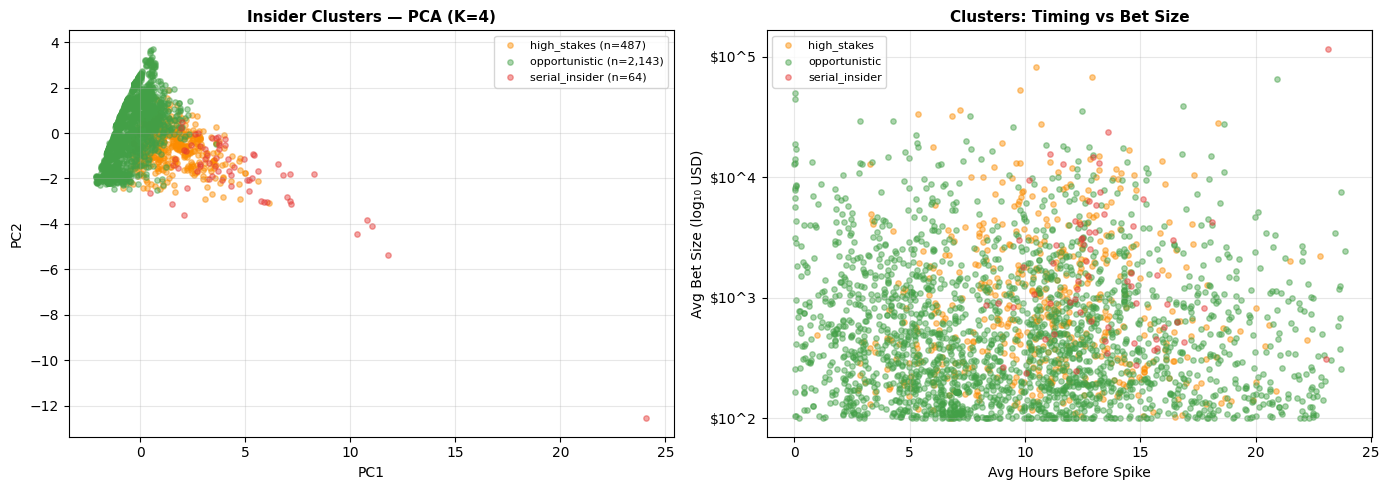

Saved: classify_charts/cluster_scatter.png


In [16]:
# PCA to 2D for scatter
pca = PCA(k=2, inputCol="features_scaled", outputCol="pca_vec")
pca_model = pca.fit(insider_scaled)
clustered_pca = pca_model.transform(clustered)

clustered_pd = clustered_pca.select(
    "prediction",
    "avg_bet_size_usd",
    "avg_hours_before_spike",
    "num_markets_traded",
    "win_rate",
    "pca_vec",
).toPandas()
clustered_pd["pc1"] = clustered_pd["pca_vec"].apply(lambda v: float(v[0]))
clustered_pd["pc2"] = clustered_pd["pca_vec"].apply(lambda v: float(v[1]))
clustered_pd["cluster_label"] = clustered_pd["prediction"].map(cluster_labels)

palette = {"serial_insider": "#E53935", "high_stakes": "#FB8C00", "opportunistic": "#43A047"}
# Fallback for extra clusters
fallback = ["#8E24AA", "#00ACC1"]
for lbl in clustered_pd["cluster_label"].unique():
    if lbl not in palette:
        palette[lbl] = fallback.pop(0) if fallback else "#757575"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PCA scatter
ax = axes[0]
for lbl, grp in clustered_pd.groupby("cluster_label"):
    ax.scatter(grp["pc1"], grp["pc2"],
               label=f"{lbl} (n={len(grp):,})",
               color=palette.get(lbl, "#757575"),
               alpha=0.45, s=15)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"Insider Clusters — PCA (K={best_k})", fontsize=11, fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: timing vs bet size
ax = axes[1]
for lbl, grp in clustered_pd.groupby("cluster_label"):
    ax.scatter(
        grp["avg_hours_before_spike"],
        np.log10(grp["avg_bet_size_usd"].clip(lower=1)),
        label=lbl,
        color=palette.get(lbl, "#757575"),
        alpha=0.45, s=15,
    )
ax.set_xlabel("Avg Hours Before Spike")
ax.set_ylabel("Avg Bet Size (log₁₀ USD)")
ax.set_title("Clusters: Timing vs Bet Size", fontsize=11, fontweight="bold")
yticks = [2, 3, 4, 5]
ax.set_yticks(yticks)
ax.set_yticklabels([f"$10^{t}" for t in yticks])
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CHART_DIR / "cluster_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: classify_charts/cluster_scatter.png")

> **Chart interpretation — Cluster Scatter:**
>
> **Left (PCA):** The first two principal components capture the dominant variance directions in the 9-feature space. Well-separated colour blobs indicate clearly distinct clusters. Overlapping blobs (low silhouette) mean the insider group is relatively homogeneous on the measured features.
>
> **Right (timing vs bet size):** The most interpretable 2D projection. Wallets in the top-right are the strongest insider candidates: they bet early (high hours before spike) *and* deploy large capital. Wallets in the bottom-left are low-capital, last-minute actors — more consistent with noise trading or public-information front-running.

---

## 8. Forward Validation — Active Markets

We run the trained classifier on wallets that were active in the three unresolved markets (`us-forces-iran-mar31`, `us-iran-ceasefire-jun30`, `china-invades-taiwan-2026`). These markets have not yet resolved, so we cannot verify correctness — but we can record which wallets the model flags as high-risk for post-resolution evaluation.

In [17]:
t0 = time.time()
suspects = (
    spark.read
    .format("bigquery")
    .option("table", f"{PROJECT}.{DATASET}.suspect_wallets")
    .load()
)

active_wallet_addrs = (
    suspects
    .filter(F.col("market_slug").isin(ACTIVE_MARKETS))
    .select("wallet_address", "market_slug")
    .distinct()
)

active_features = (
    labeled_vec
    .join(active_wallet_addrs.select("wallet_address").distinct(),
          on="wallet_address", how="inner")
)

n_active = active_features.count()
print(f"Active-market wallets with feature vectors : {n_active:,}  ({time.time()-t0:.1f}s)")

Active-market wallets with feature vectors : 5,498  (1.9s)


In [18]:
active_preds = rf_model.transform(active_features)

# vector_to_array (pyspark.ml.functions) converts VectorUDT → array for element access
active_preds = active_preds.withColumn(
    "label_probability",
    F.round(vector_to_array(F.col("probability"))[1], 4),
)

active_preds = active_preds.withColumn(
    "risk_category",
    F.when(F.col("label_probability") >= 0.8, "high_risk")
    .when(F.col("label_probability") >= 0.5, "medium_risk")
    .otherwise("low_risk")
)

print("Risk category distribution in active markets:")
active_preds.groupBy("risk_category").count().orderBy("risk_category").show()

print("Top 15 active-market wallets by insider probability:")
active_preds.select(
    "wallet_address",
    F.round("label_probability", 4).alias("p_insider"),
    "risk_category",
    F.round("avg_bet_size_usd", 0).alias("avg_bet_usd"),
    "num_markets_traded",
    F.round("avg_hours_before_spike", 1).alias("avg_hrs"),
    F.round("win_rate", 4).alias("win_rate"),
).orderBy(F.desc("label_probability")).show(15, truncate=False)

Risk category distribution in active markets:


26/05/03 10:21:33 WARN DAGScheduler: Broadcasting large task binary with size 1013.8 KiB


+-------------+-----+
|risk_category|count|
+-------------+-----+
|    high_risk|  463|
|     low_risk| 4948|
|  medium_risk|   87|
+-------------+-----+

Top 15 active-market wallets by insider probability:


+------------------------------------------+---------+-------------+-----------+------------------+-------+--------+
|wallet_address                            |p_insider|risk_category|avg_bet_usd|num_markets_traded|avg_hrs|win_rate|
+------------------------------------------+---------+-------------+-----------+------------------+-------+--------+
|0xad2e15fe68e7de020f4416d7a8b20d388539d9bd|0.9925   |high_risk    |4319.0     |2                 |3.9    |1.0     |
|0xc98399e7fc02319d8324b0791ae2f58a6dc1ebf0|0.9925   |high_risk    |188.0      |2                 |14.5   |1.0     |
|0x22f1e1f064afdc2775c2e18cbb67d03f2aff6415|0.9908   |high_risk    |305.0      |2                 |16.1   |1.0     |
|0xea1d5ac2d4635a31a1fb6cab7653df4958ece993|0.9906   |high_risk    |131.0      |2                 |8.5    |1.0     |
|0x539d01b1c4d860570a3ea35aaf87168a1f351e69|0.9894   |high_risk    |1448.0     |2                 |7.2    |1.0     |
|0x8eac8fb705b60197a3395bf9af2d45ec8a483600|0.989    |high_risk 

26/05/03 10:21:34 WARN DAGScheduler: Broadcasting large task binary with size 1007.1 KiB


> **What this output means:**
>
> These are the wallets the model believes are most likely insiders based on their behaviour in the active (unresolved) markets. `label_probability` = the model's estimated probability that the wallet is an insider. `risk_category` buckets this into high (≥0.8), medium (0.5–0.8), and low (<0.5).
>
> After these markets resolve, the `risk_category = high_risk` wallets that correctly bet the winning side will serve as the forward validation precision metric — confirming whether the model generalises beyond the retrospective resolved markets.

### 8.1 Prediction Probability Distribution

26/05/03 10:21:35 WARN DAGScheduler: Broadcasting large task binary with size 1002.5 KiB


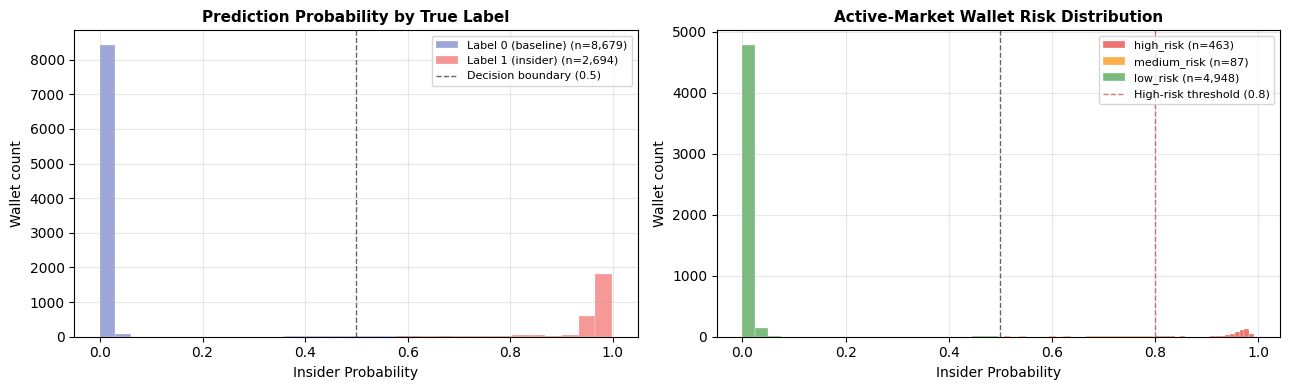

Saved: classify_charts/prediction_distribution.png


In [19]:
# Gather probabilities for all wallets (train+test combined)
all_preds = rf_model.transform(labeled_vec).withColumn(
    "label_probability",
    F.round(vector_to_array(F.col("probability"))[1], 4),
)
all_preds_pd = all_preds.select("label", "label_probability").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: probability distribution by true label
ax = axes[0]
for lbl, color, name in [(0, "#5C6BC0", "Label 0 (baseline)"), (1, "#EF5350", "Label 1 (insider)")]:
    subset = all_preds_pd[all_preds_pd["label"] == lbl]["label_probability"]
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=f"{name} (n={len(subset):,})",
            edgecolor="white", linewidth=0.3)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.6, label="Decision boundary (0.5)")
ax.set_xlabel("Insider Probability")
ax.set_ylabel("Wallet count")
ax.set_title("Prediction Probability by True Label", fontsize=11, fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: active-market wallet probability distribution
active_prob_pd = active_preds.select("label_probability", "risk_category").toPandas()
ax = axes[1]
colors_cat = {"high_risk": "#E53935", "medium_risk": "#FB8C00", "low_risk": "#43A047"}
for cat in ["high_risk", "medium_risk", "low_risk"]:
    subset = active_prob_pd[active_prob_pd["risk_category"] == cat]["label_probability"]
    if len(subset) > 0:
        ax.hist(subset, bins=20, alpha=0.7, color=colors_cat[cat],
                label=f"{cat} (n={len(subset):,})", edgecolor="white", linewidth=0.3)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.axvline(0.8, color="#B71C1C", linestyle="--", linewidth=1, alpha=0.6, label="High-risk threshold (0.8)")
ax.set_xlabel("Insider Probability")
ax.set_ylabel("Wallet count")
ax.set_title("Active-Market Wallet Risk Distribution", fontsize=11, fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CHART_DIR / "prediction_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: classify_charts/prediction_distribution.png")

> **Chart interpretation — Prediction Probability Distribution:**
>
> **Left:** A well-calibrated model should show label-0 wallets clustered near probability 0 and label-1 wallets near probability 1, with minimal overlap around 0.5. Wide overlap means the model is uncertain — which is expected here since the insider class (label 1) is defined by the same features the model uses.
>
> **Right:** Active-market wallets by risk category. The red bars (high_risk ≥ 0.8) are the wallets to watch — if these markets resolve in the direction they bet on, it becomes evidence of either insider knowledge or exceptional forecasting skill.

---

## 9. Write `ml_results` to BigQuery

In [20]:
# Cluster assignments only exist for insider-labelled wallets
cluster_df = clustered.select(
    "wallet_address",
    F.col("prediction").cast("int").alias("cluster"),
)

# Map cluster IDs to interpretive labels using Python dict
mapping_expr = F.create_map(
    *[F.lit(x) for pair in [(k, v) for k, v in cluster_labels.items()] for x in pair]
)

ml_results = (
    all_preds
    .join(cluster_df, on="wallet_address", how="left")
    .withColumn(
        "cluster_label",
        F.when(F.col("cluster").isNotNull(), mapping_expr[F.col("cluster")])
        .otherwise(F.lit("not_clustered"))
    )
    .select(
        "wallet_address",
        F.col("label").cast("int").alias("label"),
        "label_probability",
        "cluster",
        "cluster_label",
        "num_markets_traded",
        F.round("avg_bet_size_usd", 2).alias("avg_bet_size_usd"),
        F.round("avg_hours_before_spike", 2).alias("avg_hours_before_spike"),
        F.round("win_rate", 4).alias("win_rate"),
    )
)

t0 = time.time()
(
    ml_results.repartition(2)
    .write
    .format("bigquery")
    # .option("table", f"{PROJECT}.{DATASET}.ml_results")  # v1
        .option("table", f"{PROJECT}.{DATASET}.ml_results_v2")  # v2
    .option("writeMethod", "direct")
    .mode("overwrite")
    .save()
)

n_written = ml_results.count()
print(f"ml_results written : {n_written:,} rows  ({time.time()-t0:.1f}s)")

print("\nLabel distribution in ml_results:")
ml_results.groupBy("label", "cluster_label").count().orderBy("label", "cluster_label").show(truncate=False)

26/05/03 10:21:37 WARN DAGScheduler: Broadcasting large task binary with size 1046.6 KiB


ml_results written : 11,373 rows  (4.7s)

Label distribution in ml_results:


+-----+--------------+-----+
|label|cluster_label |count|
+-----+--------------+-----+
|0    |not_clustered |8679 |
|1    |high_stakes   |487  |
|1    |opportunistic |2143 |
|1    |serial_insider|64   |
+-----+--------------+-----+



> **What this output means:**
>
> `polymarket.ml_results` is now in BigQuery. Schema:
> - `wallet_address` — primary key
> - `label` — 0 or 1 (heuristic + known-suspect override)
> - `label_probability` — RF model's insider probability (0.0 to 1.0)
> - `cluster` / `cluster_label` — K-Means cluster assignment for insider wallets; `not_clustered` for label-0 wallets
> - `num_markets_traded`, `avg_bet_size_usd`, `avg_hours_before_spike`, `win_rate` — key features for Phase 7 visualisation

---

## 10. Summary

In [21]:
high_risk_active = active_preds.filter(F.col("risk_category") == "high_risk").count()

print("=" * 58)
print("Phase 6 — ML Classification & Clustering Summary")
print("=" * 58)
print(f"Total wallets classified         : {n_total:,}")
print(f"Label 1 (potential insider)      : {n1_final:,}  ({n1_final/n_total*100:.1f}%)")
print(f"Label 0 (baseline)               : {n0_final:,}")
print()
print(f"Random Forest — test metrics:")
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  F1        : {f1:.4f}")
print(f"  AUC-ROC   : {auc_roc:.4f}")
print()
print(f"K-Means (K={best_k}, silhouette={sil_scores[best_k]:.4f}):")
for cid, lbl in sorted(cluster_labels.items()):
    n = int(profile_pd.loc[cid, "n_wallets"])
    print(f"  Cluster {cid} ({lbl}) : {n:,} wallets")
print()
print(f"Forward validation:")
print(f"  Active-market wallets scored   : {n_active:,}")
print(f"  High-risk (p_insider >= 0.8)   : {high_risk_active:,}")
print()
print("BigQuery table written:")
print("  polymarket.ml_results")
print()
print("Charts saved to: classify_charts/")
print("  feature_importance.png")
print("  cluster_scatter.png")
print("  prediction_distribution.png")

Phase 6 — ML Classification & Clustering Summary
Total wallets classified         : 11,373
Label 1 (potential insider)      : 2,694  (23.7%)
Label 0 (baseline)               : 8,679

Random Forest — test metrics:
  Accuracy  : 0.9903
  F1        : 0.9904
  AUC-ROC   : 0.9995

K-Means (K=4, silhouette=0.3705):
  Cluster 0 (opportunistic) : 925 wallets
  Cluster 1 (high_stakes) : 487 wallets
  Cluster 2 (opportunistic) : 1,218 wallets
  Cluster 3 (serial_insider) : 64 wallets

Forward validation:
  Active-market wallets scored   : 5,498
  High-risk (p_insider >= 0.8)   : 463

BigQuery table written:
  polymarket.ml_results

Charts saved to: classify_charts/
  feature_importance.png
  cluster_scatter.png
  prediction_distribution.png


26/05/03 10:21:42 WARN DAGScheduler: Broadcasting large task binary with size 1000.3 KiB


---

## 11. Stop Spark

In [22]:
spark.stop()
print("Spark stopped")

Spark stopped
